# Brain Tumor Detection: Image Preprocessing

This notebook covers the first step of the brain tumor detection project: preprocessing the MRI images. This includes loading the images, resizing them, and converting them to grayscale.

## 1. Import Libraries

In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

## 2. Define Paths and Parameters

In [14]:
# Set the path to the dataset
data_dir = r'../data/Brain Tumor MRI Dataset'
train_dir = os.path.join(data_dir, 'Training')
test_dir = os.path.join(data_dir, 'Testing')

# Image parameters
img_width, img_height = 150, 150

## 3. Load and Preprocess Data

In [15]:
def load_data(data_dir):
    images = []
    labels = []
    for category in os.listdir(data_dir):
        category_dir = os.path.join(data_dir, category)
        if not os.path.isdir(category_dir):
            continue
        label = os.path.basename(category)
        for image_name in tqdm(os.listdir(category_dir), desc=f'Loading {label}'):
            image_path = os.path.join(category_dir, image_name)
            try:
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                if image is None:
                    print(f"Warning: Could not read image {image_path}. Skipping.")
                    continue
                image = cv2.resize(image, (img_width, img_height))
                images.append(image)
                labels.append(label)
            except Exception as e:
                print(f"Error loading image {image_path}: {e}")
    return np.array(images), np.array(labels)

X_train, y_train = load_data(train_dir)
X_test, y_test = load_data(test_dir)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Loading pituitary: 100%|██████████| 400/400 [00:00<00:00, 915.53it/s]

X_train shape: (5600, 150, 150)
y_train shape: (5600,)
X_test shape: (1600, 150, 150)
y_test shape: (1600,)


## 4. Display a Sample Image

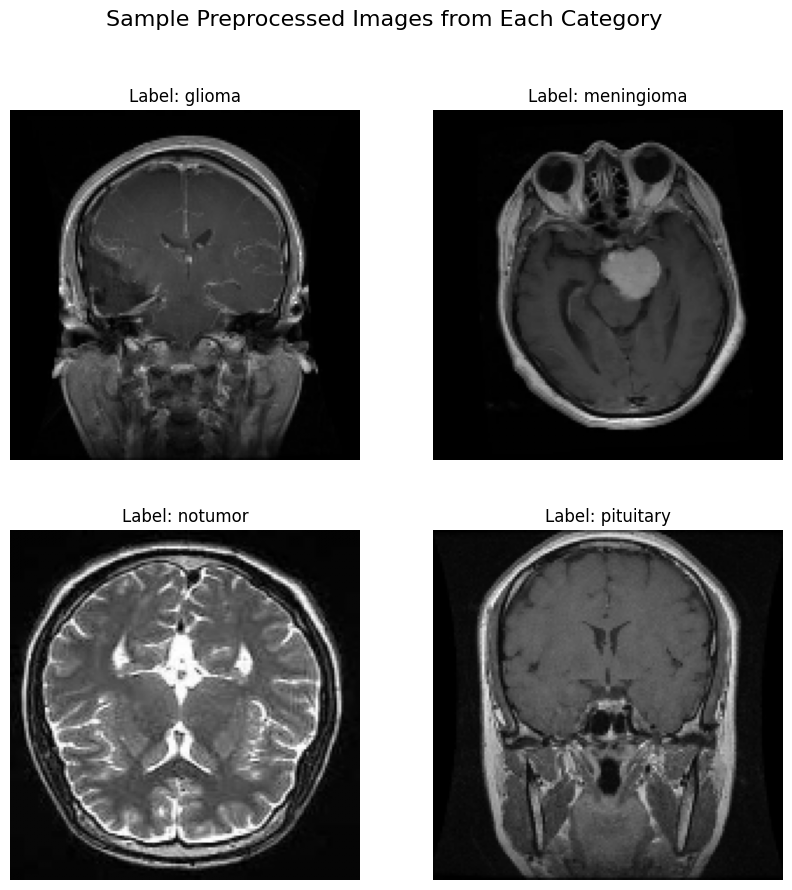

In [16]:
# Display a sample image from each category
categories = np.unique(y_train)
plt.figure(figsize=(10, 10))
for i, category in enumerate(categories):
    # Find the first image of this category
    index = np.where(y_train == category)[0][0]
    plt.subplot(2, 2, i + 1)
    plt.imshow(X_train[index], cmap='gray')
    plt.title(f"Label: {y_train[index]}")
    plt.axis('off')
plt.suptitle("Sample Preprocessed Images from Each Category", fontsize=16)
plt.show()